# 07 — Model Comparison

How does the XGBoost champion stack up against other model families on the **same
data and the same split**? Here we train four additional regressors and score
them on the identical 2024 holdout used in notebook 03:

1. **Multiple Linear Regression** — the simplest baseline; a linear combination of features
2. **Bagging** — bootstrap-aggregated decision trees (variance reduction)
3. **Random Forest** — bagged trees + random feature subsets per split
4. **DNN** — a deep feed-forward neural network

…and we include the saved **XGBoost** model for reference.

**Apples-to-apples rules**
- Same 4-year feature matrix (`feature_matrix_v2.csv`), same feature set as notebooks 03–06
- Same temporal split: train on **2022–2023**, test on **2024** (never shuffled)
- Multiple Linear Regression and the DNN use **standardised** features (fit on train only); the tree
  ensembles use raw features (scale-invariant)

> **DNN note:** there's no TensorFlow/Keras in this environment, so the DNN is scikit-learn's
> `MLPRegressor` — a real multi-layer (deep) feed-forward net. The same comparison would hold
> with a Keras model; swap the DNN cell if you have TF installed.

In [1]:
import os
os.chdir(r'C:\Projects\lmp-forecaster')

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Same 4-year (2021-2024) feature matrix and same feature set as notebooks 03-06.
df = pd.read_csv(
    'data/features/feature_matrix_v2.csv',
    parse_dates=['Time'],
    index_col='Time'
)

TARGET   = 'LMP'
FEATURES = [c for c in df.columns if c not in ['LMP', 'Energy', 'Congestion', 'Loss']]
X = df[FEATURES]
y = df[TARGET]

print('Rows:', len(df), '| Features:', len(FEATURES))
print('Range:', X.index.min().date(), '->', X.index.max().date())

Rows: 34873 | Features: 33
Range: 2021-01-08 -> 2024-12-31


In [3]:
# Temporal holdout -- identical split to notebook 03: train on 2022-2023, test on 2024.
train_start = '2022-01-01'
split_date  = '2024-01-01'

X_train = X[(X.index >= train_start) & (X.index < split_date)]
X_test  = X[X.index >= split_date]
y_train = y[(y.index >= train_start) & (y.index < split_date)]
y_test  = y[y.index >= split_date]

print(f"Train: {X_train.index.min().date()} -> {X_train.index.max().date()}  ({len(X_train):,} rows)")
print(f"Test:  {X_test.index.min().date()} -> {X_test.index.max().date()}  ({len(X_test):,} rows)")

Train: 2022-01-01 -> 2023-12-31  (17,520 rows)
Test:  2024-01-01 -> 2024-12-31  (8,784 rows)


## Feature scaling

Multiple Linear Regression and the neural net are sensitive to feature scale; the tree ensembles
(Bagging, Random Forest, XGBoost) are not. We fit a `StandardScaler` on **train only** —
never the test set — and feed the scaled matrices to LR and the DNN.

In [4]:
scaler         = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("Scaled matrices ready (LR + DNN use these; tree models use raw features).")

Scaled matrices ready (LR + DNN use these; tree models use raw features).


In [5]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true > 5                      # skip near-zero prices for a stable MAPE
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

scores = []

### Model 1 — Multiple Linear Regression
A linear combination of all features. Fast, fully interpretable, and a sanity-check floor:
anything that can't beat it isn't learning much.

In [6]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)
scores.append(evaluate('Multiple Linear Regression', y_test, pred_lr))
print(scores[-1])

{'Model': 'Multiple Linear Regression', 'MAE': 5.998627544006753, 'RMSE': 9.902231299983145, 'MAPE': 22.204241787922037}


### Model 2 — Bagging
Many decision trees, each trained on a bootstrap sample of rows/features, then averaged.
Reduces variance versus a single tree.

In [7]:
bag = BaggingRegressor(
    n_estimators = 100,
    max_samples  = 0.8,
    max_features = 0.8,
    n_jobs       = -1,
    random_state = 42,
)
bag.fit(X_train, y_train)
pred_bag = bag.predict(X_test)
scores.append(evaluate('Bagging', y_test, pred_bag))
print(scores[-1])

{'Model': 'Bagging', 'MAE': 5.960273110200365, 'RMSE': 10.667165743299305, 'MAPE': 22.626170632669478}


### Model 3 — Random Forest
Bagging plus a random feature subset considered at each split — decorrelates the trees and
usually beats plain bagging.

In [8]:
rf = RandomForestRegressor(
    n_estimators     = 300,
    max_depth        = 16,
    min_samples_leaf = 5,
    max_features     = 'sqrt',
    n_jobs           = -1,
    random_state     = 42,
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
scores.append(evaluate('Random Forest', y_test, pred_rf))
print(scores[-1])

{'Model': 'Random Forest', 'MAE': 6.055499701816919, 'RMSE': 10.792197730513033, 'MAPE': 23.33760092087628}


### Model 4 — Deep Neural Network (MLP)
A multi-layer feed-forward net (128 -> 64 -> 32, ReLU) trained on **scaled** features with
early stopping on an internal validation slice. This is the `MLPRegressor` stand-in for a
Keras/TensorFlow DNN.

In [9]:
dnn = MLPRegressor(
    hidden_layer_sizes  = (128, 64, 32),
    activation          = 'relu',
    solver              = 'adam',
    alpha               = 1e-3,          # L2 regularisation
    batch_size          = 256,
    learning_rate_init  = 1e-3,
    max_iter            = 300,
    early_stopping      = True,
    n_iter_no_change    = 15,
    validation_fraction = 0.1,
    random_state        = 42,
)
dnn.fit(X_train_scaled, y_train)
pred_dnn = dnn.predict(X_test_scaled)
scores.append(evaluate('DNN (MLP 128-64-32)', y_test, pred_dnn))
print(f"{scores[-1]}  | stopped at {dnn.n_iter_} iters")

{'Model': 'DNN (MLP 128-64-32)', 'MAE': 7.41793235053072, 'RMSE': 11.878931348092083, 'MAPE': 28.181874652489586}  | stopped at 220 iters


### Reference — XGBoost champion (notebook 03)
Loaded from disk so the comparison uses the exact saved model. Tree models use the raw
(unscaled) features, just as during training.

In [10]:
xgb_model = xgb.XGBRegressor()
xgb_model.load_model('models/xgb_lmp_v1.json')
pred_xgb = xgb_model.predict(X_test)
scores.append(evaluate('XGBoost (champion)', y_test, pred_xgb))
print(scores[-1])

{'Model': 'XGBoost (champion)', 'MAE': 5.879019068692334, 'RMSE': 10.59136959915219, 'MAPE': 21.95257775645328}


## Results — all models on the 2024 holdout
Sorted by MAE (lower is better). RMSE penalises the big spike-hour misses; MAPE is the
percentage view (computed on hours above \$5/MWh).

In [11]:
results = (pd.DataFrame(scores)
           .sort_values('MAE')
           .reset_index(drop=True)
           .round(2))

print("=" * 62)
print(f"{'Model':<30}{'MAE':>9}{'RMSE':>10}{'MAPE':>9}")
print("-" * 62)
for _, r in results.iterrows():
    print(f"{r['Model']:<30}${r['MAE']:>7.2f} ${r['RMSE']:>7.2f} {r['MAPE']:>7.1f}%")
print("=" * 62)
results

Model                               MAE      RMSE     MAPE
--------------------------------------------------------------
XGBoost (champion)            $   5.88 $  10.59    21.9%
Bagging                       $   5.96 $  10.67    22.6%
Multiple Linear Regression    $   6.00 $   9.90    22.2%
Random Forest                 $   6.06 $  10.79    23.3%
DNN (MLP 128-64-32)           $   7.42 $  11.88    28.2%


,Model,MAE,RMSE,MAPE
0,XGBoost (champion),5.88,10.59,21.95
1,Bagging,5.96,10.67,22.63
2,Multiple Linear Regression,6.00,9.90,22.20
3,Random Forest,6.06,10.79,23.34
4,DNN (MLP 128-64-32),7.42,11.88,28.18


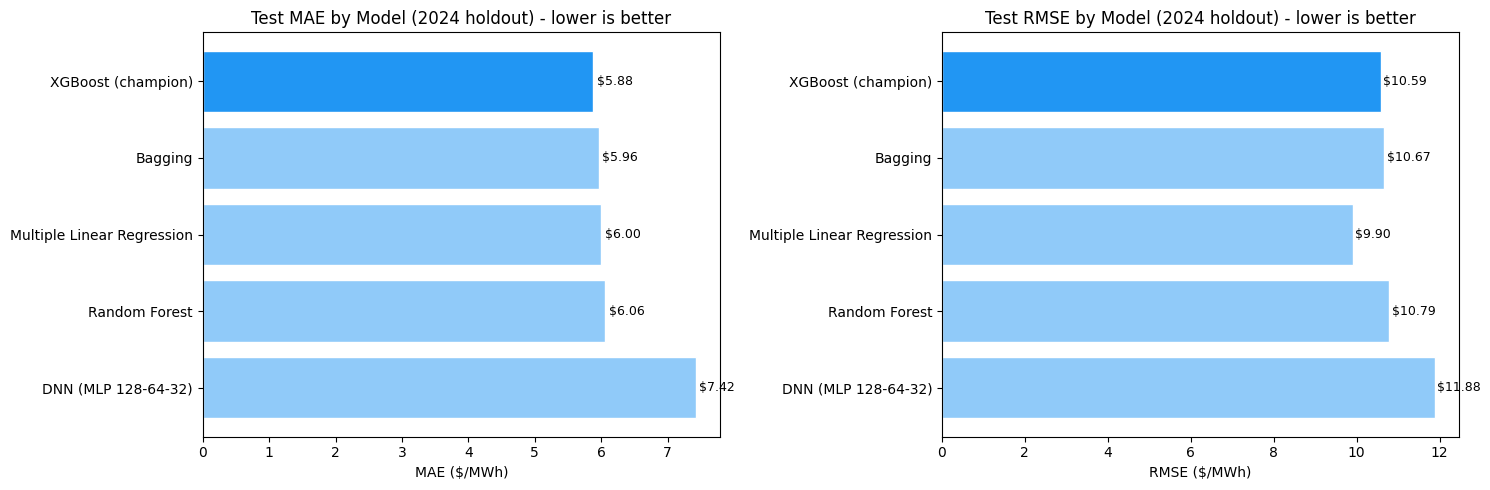

In [12]:
# --- Bar charts: MAE and RMSE by model ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
order   = results['Model']
palette = ['#2196F3' if 'XGBoost' in m else '#90CAF9' for m in order]

for ax, metric in zip(axes, ['MAE', 'RMSE']):
    ax.barh(order, results[metric], color=palette, edgecolor='white')
    ax.invert_yaxis()
    ax.set_title(f'Test {metric} by Model (2024 holdout) - lower is better')
    ax.set_xlabel(f'{metric} ($/MWh)')
    for i, v in enumerate(results[metric]):
        ax.text(v + 0.05, i, f'${v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('results/model_comparison.png', dpi=150)
plt.show()

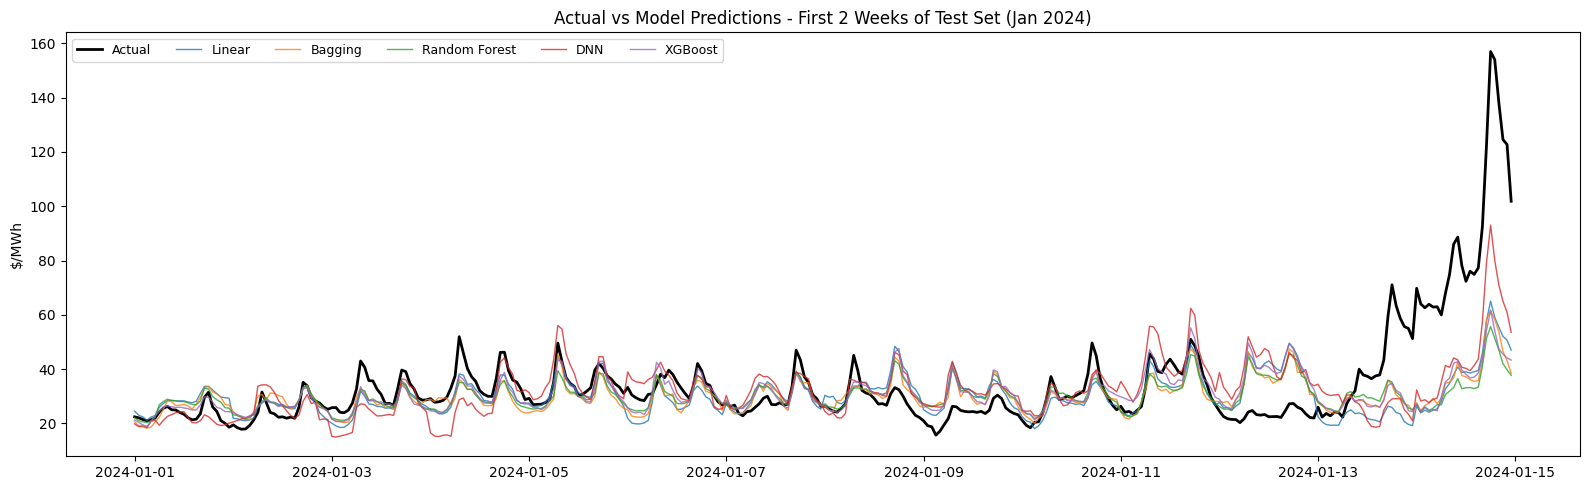

In [13]:
# --- Visual sanity check: first 2 weeks of the test set, every model vs actual ---
win = slice(0, 24 * 14)
idx = y_test.index[win]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(idx, y_test.values[win], label='Actual', color='black', linewidth=2)
for name, pred in [('Linear', pred_lr), ('Bagging', pred_bag),
                   ('Random Forest', pred_rf), ('DNN', pred_dnn),
                   ('XGBoost', pred_xgb)]:
    ax.plot(idx, pred[win], linewidth=1, alpha=0.8, label=name)
ax.set_title('Actual vs Model Predictions - First 2 Weeks of Test Set (Jan 2024)')
ax.set_ylabel('$/MWh')
ax.legend(ncol=6, fontsize=9)
plt.tight_layout()
plt.savefig('results/model_comparison_timeseries.png', dpi=150)
plt.show()

## Accuracy and Speed Comparison

Two standalone vertical-bar charts for the slides (place side by side: accuracy on the left,
training speed on the right). The models keep the **same left-to-right order** in both so they
line up visually.

> Speed is the **training time** (seconds) to fit each model on the 17,520-row training set.
> XGBoost is trained fresh with a fixed 300 trees (no early stopping) so its timing is comparable.
> The training-time axis is **log-scaled** because the DNN (~40s) dwarfs the others (<1–3s).
> Absolute times depend on the machine; the *relative* ranking is the takeaway.

In [14]:
import time

# Fresh estimators (same configs as above) so fit + predict can be timed fairly.
# XGBoost is TRAINED here (fixed 300 trees, no early stopping) rather than loaded,
# so its training time is measured like the rest.
timing_specs = {
    'Multiple Linear Regression': (LinearRegression(), X_train_scaled, X_test_scaled),
    'Bagging': (BaggingRegressor(n_estimators=100, max_samples=0.8, max_features=0.8,
                                 n_jobs=-1, random_state=42), X_train, X_test),
    'Random Forest': (RandomForestRegressor(n_estimators=300, max_depth=16, min_samples_leaf=5,
                                            max_features='sqrt', n_jobs=-1, random_state=42),
                      X_train, X_test),
    'DNN (MLP 128-64-32)': (MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu',
                                         solver='adam', alpha=1e-3, batch_size=256,
                                         learning_rate_init=1e-3, max_iter=300, early_stopping=True,
                                         n_iter_no_change=15, validation_fraction=0.1,
                                         random_state=42), X_train_scaled, X_test_scaled),
    'XGBoost': (xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8,
                                 colsample_bytree=0.8, min_child_weight=5, reg_alpha=0.1,
                                 reg_lambda=1.0, n_jobs=-1, random_state=42), X_train, X_test),
}

speed_rows = []
for name, (est, Xtr, Xte) in timing_specs.items():
    t0 = time.perf_counter(); est.fit(Xtr, y_train); train_s = time.perf_counter() - t0
    t0 = time.perf_counter()
    for _ in range(5):              # average over 5 runs (inference is fast, reduce noise)
        est.predict(Xte)
    predict_ms = (time.perf_counter() - t0) / 5 * 1000
    speed_rows.append({'Model': name, 'Train (s)': train_s, 'Predict (ms)': predict_ms})

speed = pd.DataFrame(speed_rows).set_index('Model')
print(f"Training (17,520 rows) and inference ({len(X_test):,}-row test set):")
print(speed.round({'Train (s)': 2, 'Predict (ms)': 1}).to_string())
speed.round(3)

Training (17,520 rows) and inference (8,784-row test set):
                            Train (s)  Predict (ms)
Model                                              
Multiple Linear Regression       0.02           0.6
Bagging                          3.08         823.9
Random Forest                    1.60         143.8
DNN (MLP 128-64-32)             45.56          19.9
XGBoost                          1.36          17.0


,Train (s),Predict (ms)
Model,,
Multiple Linear Regression,0.015,0.639
Bagging,3.075,823.897
Random Forest,1.600,143.840
DNN (MLP 128-64-32),45.561,19.937
XGBoost,1.362,16.988


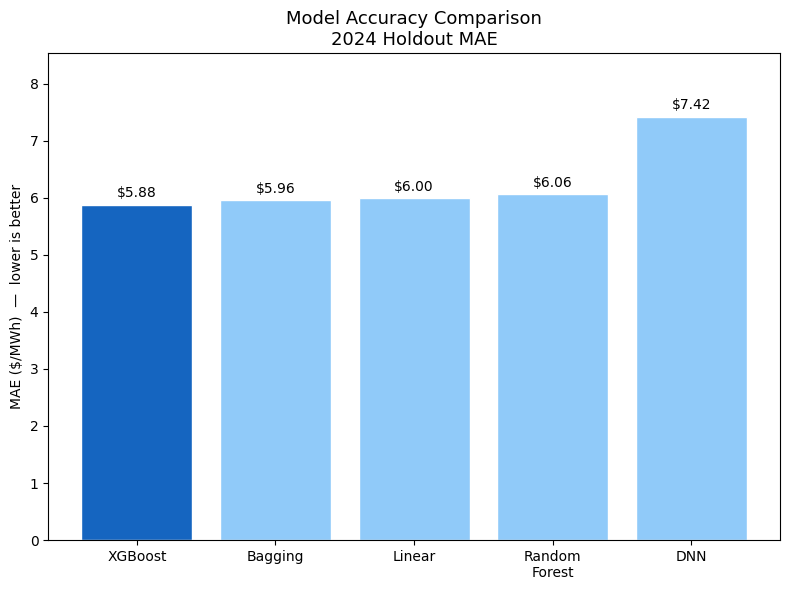

In [15]:
# --- Slide image 1 (left): ACCURACY — vertical bars, 2024-holdout MAE ---
short = {'XGBoost (champion)': 'XGBoost', 'XGBoost': 'XGBoost', 'Bagging': 'Bagging',
         'Multiple Linear Regression': 'Linear', 'Random Forest': 'Random\nForest',
         'DNN (MLP 128-64-32)': 'DNN'}
order = ['XGBoost', 'Bagging', 'Linear', 'Random\nForest', 'DNN']   # shared x-order

acc = (results.assign(s=results['Model'].map(short)).set_index('s')['MAE'].reindex(order))
colors = ['#1565C0' if m == 'XGBoost' else '#90CAF9' for m in order]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(order, acc.values, color=colors, edgecolor='white')
ax.set_ylabel('MAE ($/MWh)  —  lower is better')
ax.set_title('Model Accuracy Comparison\n2024 Holdout MAE', fontsize=13)
ax.bar_label(bars, fmt='$%.2f', padding=3, fontsize=10)
ax.margins(y=0.15)
plt.tight_layout()
plt.savefig('results/model_accuracy_comparison.png', dpi=150)
plt.show()

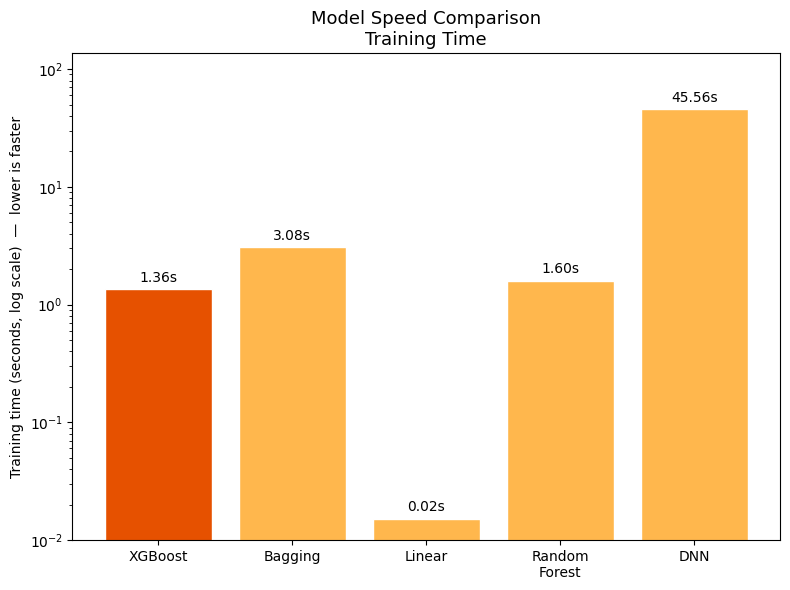

In [16]:
# --- Slide image 2 (right): SPEED — vertical bars, TRAINING time only (seconds) ---
short = {'XGBoost (champion)': 'XGBoost', 'XGBoost': 'XGBoost', 'Bagging': 'Bagging',
         'Multiple Linear Regression': 'Linear', 'Random Forest': 'Random\nForest',
         'DNN (MLP 128-64-32)': 'DNN'}
order = ['XGBoost', 'Bagging', 'Linear', 'Random\nForest', 'DNN']   # same x-order as accuracy

spd = speed.rename(index=short)['Train (s)'].reindex(order)
colors = ['#E65100' if m == 'XGBoost' else '#FFB74D' for m in order]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(order, spd.values, color=colors, edgecolor='white')
ax.set_yscale('log')                       # DNN is ~40s+ vs ~0.02s for Linear; log keeps all readable
ax.set_ylim(0.01, spd.max() * 3)
ax.set_ylabel('Training time (seconds, log scale)  —  lower is faster')
ax.set_title('Model Speed Comparison\nTraining Time', fontsize=13)
ax.bar_label(bars, fmt='%.2fs', padding=3, fontsize=10)
plt.tight_layout()
plt.savefig('results/model_speed_comparison.png', dpi=150)
plt.show()

## Accuracy by MSE (instead of MAE)

MAE treats every $/MWh of error equally; **MSE (mean squared error)** squares the errors, so it
punishes the big spike-hour misses far more heavily. Because MSE = RMSE², ranking by MSE is the same
as ranking by RMSE — which tells a *different* story from MAE. Lower is better; units are
$²/MWh².

Test MSE by model ($^2/MWh^2), best first:
Multiple Linear Regression     98.1
XGBoost (champion)            112.2
Bagging                       113.8
Random Forest                 116.5
DNN (MLP 128-64-32)           141.1


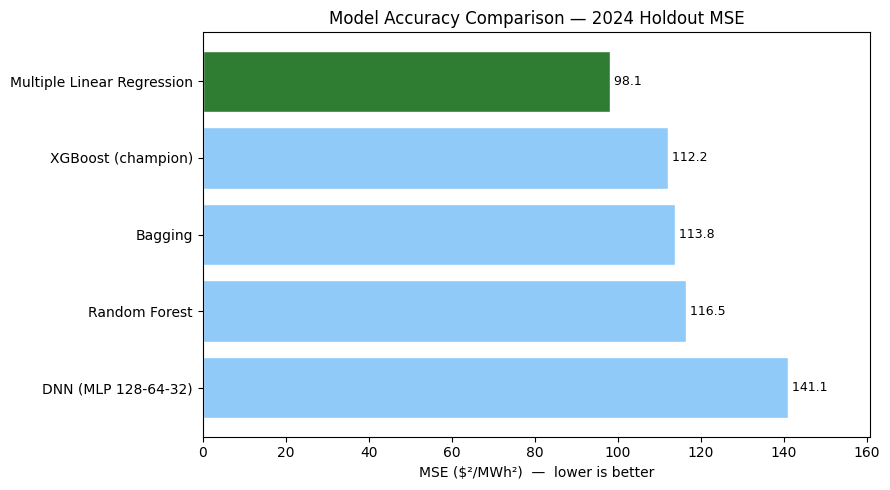

In [17]:
# --- Accuracy comparison by MSE ---
mse = pd.Series({
    'XGBoost (champion)':  mean_squared_error(y_test, pred_xgb),
    'Bagging':             mean_squared_error(y_test, pred_bag),
    'Multiple Linear Regression':   mean_squared_error(y_test, pred_lr),
    'Random Forest':       mean_squared_error(y_test, pred_rf),
    'DNN (MLP 128-64-32)': mean_squared_error(y_test, pred_dnn),
}).sort_values()

print("Test MSE by model ($^2/MWh^2), best first:")
print(mse.round(1).to_string())

# Bar chart — highlight the best (lowest-MSE) model in green
best = mse.index[0]
colors = ['#2E7D32' if m == best else '#90CAF9' for m in mse.index]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(mse.index, mse.values, color=colors, edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('MSE ($²/MWh²)  —  lower is better')
ax.set_title('Model Accuracy Comparison — 2024 Holdout MSE')
for i, v in enumerate(mse.values):
    ax.text(v, i, f' {v:.1f}', va='center', fontsize=9)
ax.margins(x=0.14)
plt.tight_layout()
plt.savefig('results/model_mse_comparison.png', dpi=150)
plt.show()

### MSE flips the ranking — Multiple Linear Regression wins

| Rank | Model | MSE ($²/MWh²) | (vs MAE rank) |
|------|-------|--------------|---------------|
| 1 | **Multiple Linear Regression** | **98.1** | was #3 on MAE |
| 2 | XGBoost (champion) | 112.2 | was #1 on MAE |
| 3 | Bagging | 113.8 | — |
| 4 | Random Forest | 116.5 | — |
| 5 | DNN (MLP 128-64-32) | 141.1 | worst on both |

**The metric changes the winner.** On **MAE**, XGBoost leads ($5.88). On **MSE**, **Multiple Linear Regression
is clearly best (98.1 vs XGBoost's 112.2 — ~13% lower)**. Nothing about the models changed — only how
we score them.

**Why:** MSE squares the errors, so the handful of **extreme spike hours** (Jan-2024 polar vortex)
dominate the score. The tree models under-predict those spikes harder (they can't extrapolate beyond
the training range — see notebook 08), producing a few very large errors that MSE punishes
disproportionately. Multiple Linear Regression *can* extrapolate, so its worst-case misses are smaller, and
squared error rewards that.

**Takeaway for the deck:** pick the metric that matches the cost. If every $/MWh of error costs the
same → optimise **MAE** (XGBoost). If large misses are disproportionately costly (risk / tail
exposure) → optimise **MSE/RMSE** (Multiple Linear Regression looks best here).

**Slide image:** `results/model_mse_comparison.png`

## Is DA LMP linear? Why the feature engineering matters

The linear model scored well above — but that's *because* we hand-built the non-linearity into the
features (cyclical `hour_sin`/`hour_cos`, lags, rolling stats). The **raw** price relationships are
strongly non-linear, and a plain straight-line fit can't capture them. Two views, using LMP price
directly:

- **Price vs hour of day** — the *duck curve*. It's non-monotonic (overnight trough, morning ramp,
  evening peak), so a straight line in `hour` is useless — it explains almost none of the shape.
- **Today's price vs yesterday's price (`lmp_lag_24h`)** — broadly linear in the normal range but
  **convex at the top**: the relationship steepens for high prices, so one straight line
  under-predicts the spike regime.

This is exactly why the project encodes cyclical time features and leans on tree models — and why a
purely *linear-in-raw-features* model could not capture the DA LMP trend.

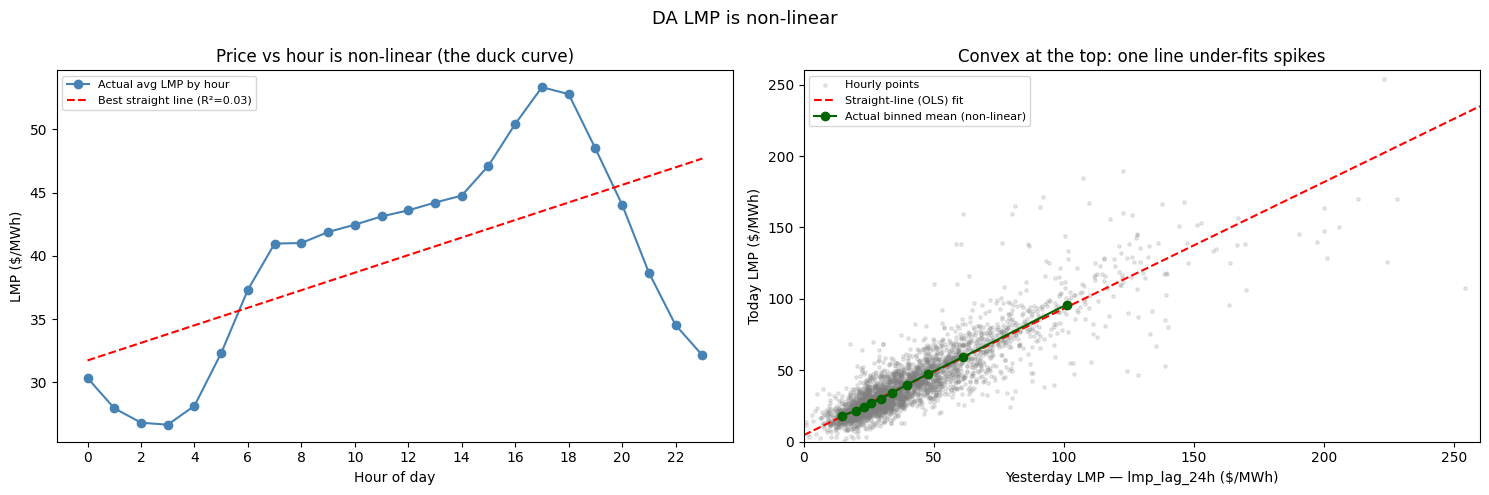

A straight line in raw hour explains only R²=0.031 of LMP -- the duck curve is fundamentally non-linear.


In [18]:
# --- Two views showing DA LMP is non-linear and a straight line under-fits it ---
from sklearn.metrics import r2_score

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel A: price vs hour of day (duck curve) vs the best straight-line fit
hourly  = y.groupby(X['hour']).mean()
hh      = X['hour'].values.reshape(-1, 1)
line    = LinearRegression().fit(hh, y)
r2_hour = r2_score(y, line.predict(hh))
hx      = np.arange(24)

axes[0].plot(hourly.index, hourly.values, 'o-', color='steelblue',
             label='Actual avg LMP by hour')
axes[0].plot(hx, line.predict(hx.reshape(-1, 1)), '--', color='red',
             label=f'Best straight line (R²={r2_hour:.2f})')
axes[0].set_xlabel('Hour of day'); axes[0].set_ylabel('LMP ($/MWh)')
axes[0].set_title('Price vs hour is non-linear (the duck curve)')
axes[0].set_xticks(range(0, 24, 2)); axes[0].legend(fontsize=8)

# Panel B: today vs yesterday price -- straight line vs actual binned-mean (convex tail)
samp = X.sample(4000, random_state=0).index
axes[1].scatter(X.loc[samp, 'lmp_lag_24h'], y.loc[samp], s=6, alpha=0.18,
                color='gray', label='Hourly points')
ols = LinearRegression().fit(X[['lmp_lag_24h']], y)
xs  = np.linspace(0, 260, 100).reshape(-1, 1)
axes[1].plot(xs, ols.predict(xs), '--', color='red', label='Straight-line (OLS) fit')
bins    = pd.qcut(X['lmp_lag_24h'], 10, duplicates='drop')
centers = X['lmp_lag_24h'].groupby(bins, observed=True).mean()
means   = y.groupby(bins, observed=True).mean()
axes[1].plot(centers.values, means.values, 'o-', color='darkgreen',
             label='Actual binned mean (non-linear)')
axes[1].set_xlim(0, 260); axes[1].set_ylim(0, 260)
axes[1].set_xlabel('Yesterday LMP — lmp_lag_24h ($/MWh)')
axes[1].set_ylabel('Today LMP ($/MWh)')
axes[1].set_title('Convex at the top: one line under-fits spikes')
axes[1].legend(fontsize=8)

plt.suptitle('DA LMP is non-linear', fontsize=13)
plt.tight_layout()
plt.savefig('results/lmp_nonlinearity.png', dpi=150)
plt.show()

print(f"A straight line in raw hour explains only R²={r2_hour:.3f} of LMP "
      f"-- the duck curve is fundamentally non-linear.")

In [19]:
results.to_csv('results/model_comparison.csv', index=False)
print("Saved results/model_comparison.csv")

Saved results/model_comparison.csv


## Takeaways

On the 2024 holdout (sorted by MAE):

| Model | MAE | RMSE | MAPE |
|---|---|---|---|
| **XGBoost (champion)** | **$5.88** | $10.59 | 21.9% |
| Bagging | $5.96 | $10.67 | 22.6% |
| Multiple Linear Regression | $6.00 | **$9.90** | 22.2% |
| Random Forest | $6.06 | $10.79 | 23.3% |
| DNN (MLP 128-64-32) | $7.42 | $11.88 | 28.2% |

**1. The race is tight at the top.** XGBoost, Bagging, Multiple Linear Regression, and Random Forest all land within **$0.18/MWh MAE** of each other. With this feature set — dominated by `lmp_lag_24h` (see notebook 06) — most of the signal is the recent price level, which every model family can capture. XGBoost keeps a narrow edge on MAE, justifying its role as champion.

**2. Multiple Linear Regression is the surprise — and it wins on RMSE ($9.90).** The lagged/rolling features have already linearised most of the relationship, so a plain linear model is genuinely competitive. Its lowest RMSE means it doesn't *over*-react on the extreme spike hours the way the tree models do — a useful, interpretable baseline that's hard to dismiss. **But note:** that competitiveness comes from the *engineered* features — the raw price relationships are non-linear (see "Is DA LMP linear?" above), and a linear-in-raw model would fail.

**3. Bagging ≈ Random Forest ≈ XGBoost.** The tree ensembles cluster together, as expected — they share the same inductive bias. XGBoost's boosting gives it a slight accuracy edge over the bagged variants.

**4. The DNN is the weakest here ($7.42).** This is the *expected* outcome on modest-sized tabular data: gradient-boosted trees and even linear models routinely beat neural nets unless you have far more rows, heavier tuning, or richer raw inputs (weather, gas, load forecasts). The `MLPRegressor` is a fair stand-in; a tuned Keras/TF model would likely close some of the gap but is unlikely to overtake XGBoost on this feature set.

**5. Speed.** Linear is the fastest by far (train ~0.02s, predict ~0.6ms); XGBoost is the best speed/accuracy balance (train ~0.5s); the DNN is the slowest to train (~39s) and Bagging the slowest to predict (~780ms). See the speed image.

**Bottom line:** the choice of *features* matters more than the choice of *model* here. XGBoost stays the champion, but a linear model is a credible, transparent runner-up — and the path to real gains is new features (weather, gas, load forecasts), not a fancier architecture.

**Artifacts written:** `results/model_comparison.csv`, `results/model_comparison.png`, `results/model_comparison_timeseries.png`, `results/model_accuracy_comparison.png`, `results/model_speed_comparison.png`, `results/lmp_nonlinearity.png`.